## **Métodos de búsqueda**

Diana Fernanda Barbosa Dueñas

756920

Ingeniería Financiera

In [160]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

In [176]:
x_train = np.array([10,2,3]).reshape(-1, 1)
y_train = np.array([-4017,-1255,2847.31363]).reshape(-1, 1)

np.random.seed(42)

In [177]:
modelo = Pipeline([('scaler', StandardScaler()), ('modelo', GaussianProcessRegressor(random_state=42))])
modelo.fit(x_train.reshape(-1, 1), y_train.reshape(-1, 1))

Pipeline(steps=[('scaler', StandardScaler()),
                ('modelo', GaussianProcessRegressor(random_state=42))])

In [178]:
# Nuevos datos
x_sim = np.linspace(2,15,10001).reshape(-1, 1)
y_sim, y_sim_std = modelo.predict(x_sim, return_std=True)

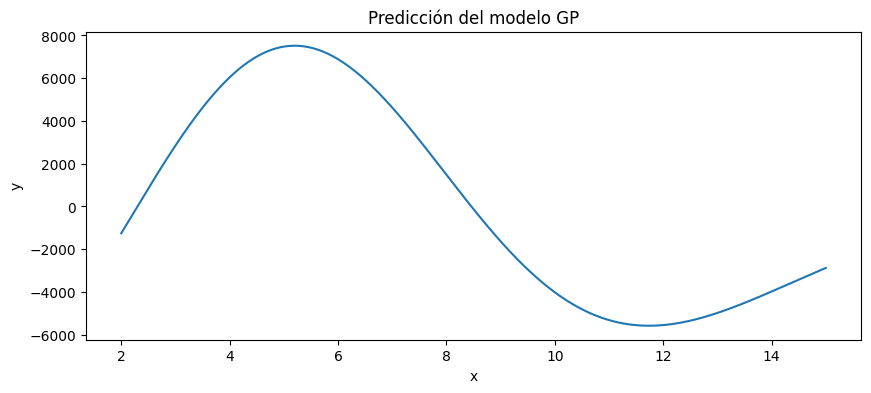

In [179]:
plt.figure(figsize=(10, 4))
plt.plot(x_sim, y_sim)
plt.xlabel('x')
plt.ylabel('y')
plt.title('Predicción del modelo GP')
plt.show()

### **Intervalo de confianza**

In [180]:
# 95%
intervalo_max = y_sim + y_sim[1]
intervalo_min = y_sim - y_sim[1]

(0.0, 3000.0)

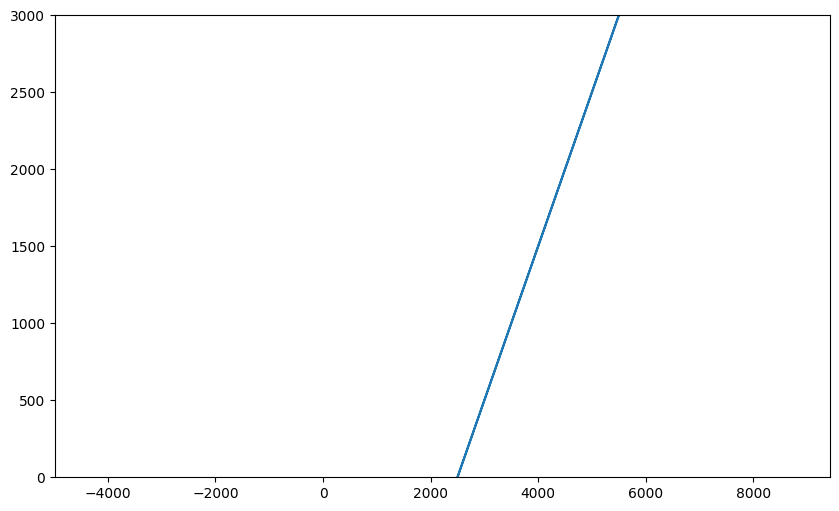

In [181]:
plt.figure(figsize=(10, 6))
plt
plt.plot(intervalo_min, intervalo_max)
plt.ylim([0,3000])

In [182]:
np.array(intervalo_max)

array([-2504.55125371, -2499.1025192 , -2493.65344108, ...,
       -4128.7866906 , -4127.39701612, -4126.00756991])

## **Nuevo Intento**

In [183]:
x_train = np.array([10,2,3,7,12,9.9963])
y_train = np.array([10,2,3,7,12,9.9963])

np.random.seed(42)

In [184]:
y_sim = np.array([10,2,3,7,12,9.9963])
y_sim_std = np.array([10,2,3,7,12,9.9963])

In [185]:
gp = GaussianProcessRegressor()
gp.fit(x_train.reshape(-1, 1), y_train.reshape(-1, 1))

GaussianProcessRegressor()

In [186]:
x_sim = np.linspace(2,15,10001).reshape(-1, 1)
y_sim, y_sim_std = gp.predict(x_sim, return_std=True)

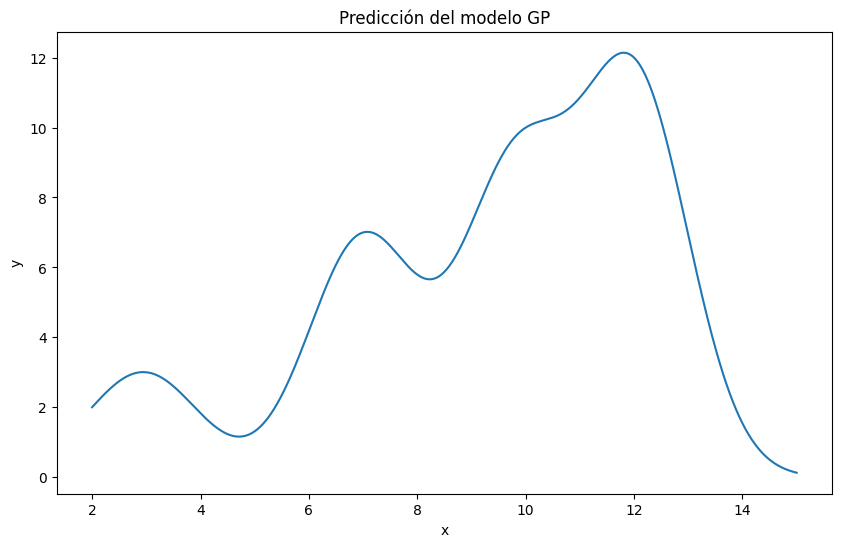

In [187]:
plt.figure(figsize=(10, 6))
plt.plot(x_sim, y_sim)
plt.xlabel('x')
plt.ylabel('y')
plt.title('Predicción del modelo GP')
plt.show()

In [130]:
np.array(intervalo_max)

array([4.00222606, 4.00445211, 4.00667768, ..., 2.12946522, 2.12897027,
       2.12847704])

## **Segundo Intento**

In [122]:
x_train = np.array([10,2,3,7,12,9.9963,9.9651,9.8741])
y_train = np.array([10,2,3,7,12,9.9963,9.9651,9.8741])

np.random.seed(42)

In [123]:
y_sim = np.array([10,2,3,7,12,9.9963,9.9651,9.8741])
y_sim_std = np.array([10,2,3,7,12,9.9963,9.9651,9.8741])

In [124]:
gp = GaussianProcessRegressor()
gp.fit(x_train.reshape(-1, 1), y_train.reshape(-1, 1))

GaussianProcessRegressor()

In [125]:
x_sim = np.linspace(2,15,10001).reshape(-1, 1)
y_sim, y_sim_std = gp.predict(x_sim, return_std=True)

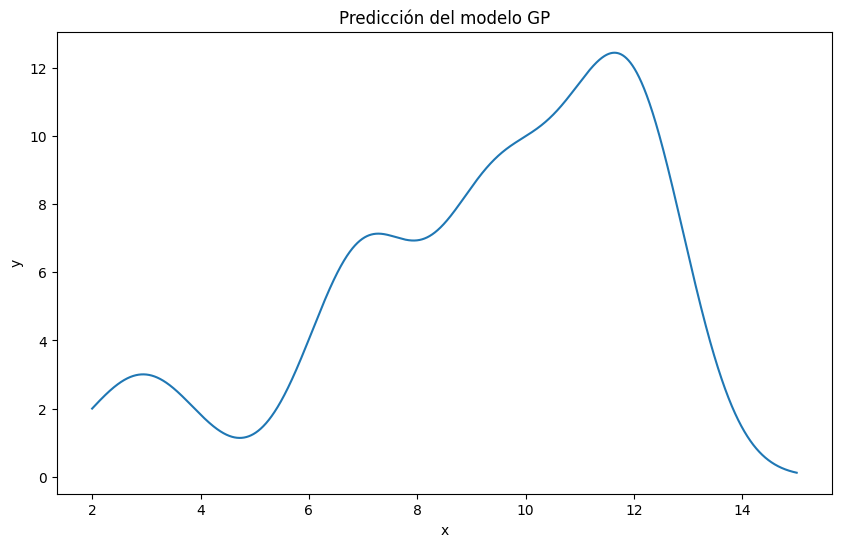

In [126]:
plt.figure(figsize=(10, 6))
plt.plot(x_sim, y_sim)
plt.xlabel('x')
plt.ylabel('y')
plt.title('Predicción del modelo GP')
plt.show()

In [127]:
np.array(intervalo_max)

array([4.00222606, 4.00445211, 4.00667768, ..., 2.12946522, 2.12897027,
       2.12847704])

## **Conclusión**

Empezamos con unos pocos puntos, y a medida que le dábamos más datos (en los intentos siguientes), el modelo aprendía mejor la relación entre "x" y "y". Lo interesante del GPR es que no solo predice un valor, sino que también nos dice qué tan seguro está de esa predicción (la incertidumbre). Así, podemos ver tanto la 'respuesta' como la 'confianza' del modelo en esa respuesta. Fue un proceso de ir mejorando el modelo añadiendo más información.